# Spatial Analysis with Python
## A practical, hands-on tour

**Anzony Quispe** · 2026

Vector + raster + big geo data, all from a Jupyter Notebook.


## What you will leave with

- A mental model of **CRS**, **lat/lon**, points / lines / polygons
- The four operations you'll use 90% of the time:
  **intersection**, **overlay**, **dissolve / disaggregate**, **spatial join**
- How to read **Shapefile**, **GeoTIFF (.tif)**, **NetCDF (.nc)**, **HDF**, **GeoParquet**
- How to **rasterize / vectorize** and compute **zonal statistics**
- How to scale to big data with **Dask-GeoPandas** and **R-tree** indexes
- How to publish interactive maps with **folium**


## 0 · Setup

Install once (uncomment the line below if you are missing anything).


In [28]:
# !pip install geopandas shapely pyproj rasterio rioxarray xarray netCDF4 h5py \
#     folium contextily mapclassify rasterstats pyarrow dask-geopandas pyogrio


In [53]:
import warnings, os
warnings.filterwarnings("ignore")
os.environ["USE_PYGEOS"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon, MultiPolygon, box

print("geopandas :", gpd.__version__)
print("shapely   :", __import__("shapely").__version__)


geopandas : 1.1.1
shapely   : 2.1.2


## 1 · Why Python for GIS?

| Click-based GIS (QGIS / ArcGIS) | Python (GeoPandas, rasterio, …) |
|---|---|
| Great for exploration | Great for **reproducibility** |
| One file at a time | Loops over thousands of files |
| Manual joins | Joins the entire pandas / numpy stack |
| Hard to scale | Dask, Parquet, parallel I/O |

> Rule of thumb: **explore in QGIS, ship in Python.**


## 2 · Latitude & Longitude

- **Latitude** (φ): −90° (South Pole) to +90° (North Pole)
- **Longitude** (λ): −180° to +180°, 0° at Greenwich
- A point on Earth = `(lon, lat)` — **x first, then y**
- These are **angles**, not distances. 1° of longitude ≠ 1° of latitude.

⚠️ In Shapely / GeoPandas the convention is `(x, y) = (lon, lat)`.
Mixing them up is the most common GIS bug.


In [51]:
lima  = Point(-77.0428, -12.0464)   # (lon, lat)
cusco = Point(-71.9675, -13.5320)

print("Lima  :", lima,  " | x=lon", lima.x,  "y=lat", lima.y)
print("Cusco :", cusco)


Lima  : POINT (-77.0428 -12.0464)  | x=lon -77.0428 y=lat -12.0464
Cusco : POINT (-71.9675 -13.532)


## 3 · Coordinate Reference Systems (CRS)

A CRS tells software **how to interpret the numbers** in a geometry.

Two families:

| Family | Units | Example | Use for |
|---|---|---|---|
| **Geographic** | degrees | `EPSG:4326` (WGS84) | sharing data, web APIs |
| **Projected**  | meters  | `EPSG:3857` (Web Mercator), UTM zones | distances, areas, buffers |

EPSG codes are the universal IDs — look them up at https://epsg.io


### The three golden rules of CRS

1. **Every dataset has a CRS.** If it doesn't, you have a bug.
2. **Never compute distance/area in a geographic CRS.** Reproject first.
3. **All layers in an analysis must share the same CRS.**


In [54]:
cities = gpd.GeoDataFrame(
    {"name": ["Lima", "Cusco", "Arequipa", "Iquitos"]},
    geometry=[
        Point(-77.0428, -12.0464),
        Point(-71.9675, -13.5320),
        Point(-71.5375, -16.3989),
        Point(-73.2536, -3.7437),
    ],
    crs="EPSG:4326",
)
cities


,name,geometry
0,Lima,POINT (-77.0428 -12.0464)
1,Cusco,POINT (-71.9675 -13.532)
2,Arequipa,POINT (-71.5375 -16.3989)
3,Iquitos,POINT (-73.2536 -3.7437)


In [55]:
print("CRS:", cities.crs)
print("Axis info:", cities.crs.axis_info[0].unit_name, "/", cities.crs.axis_info[1].unit_name)


CRS: EPSG:4326
Axis info: degree / degree


## 4 · Distance — meters, not degrees

`.distance()` returns whatever unit the CRS uses.

- In `EPSG:4326` → degrees (almost never what you want) (-180, 180), (0, 360)
- In a projected CRS → meters


In [56]:
cities

,name,geometry
0,Lima,POINT (-77.0428 -12.0464)
1,Cusco,POINT (-71.9675 -13.532)
2,Arequipa,POINT (-71.5375 -16.3989)
3,Iquitos,POINT (-73.2536 -3.7437)


In [57]:
# WRONG: degrees
d_deg = cities.geometry.iloc[0].distance(cities.geometry.iloc[1])
print(f"Lima → Cusco in degrees (meaningless): {d_deg:.3f}")

# RIGHT: reproject to UTM 18S (Peru) and measure in meters
cities_m = cities.to_crs("EPSG:32718")
d_m = cities_m.geometry.iloc[0].distance(cities_m.geometry.iloc[1])
print(f"Lima → Cusco in km: {d_m/1000:,.1f}")


Lima → Cusco in degrees (meaningless): 5.288
Lima → Cusco in km: 575.0


In [58]:
# GeoPandas can pick a sensible UTM zone for you
auto = cities.estimate_utm_crs()
print("Auto-suggested CRS:", auto)
cities.to_crs(auto).geometry.distance(cities.to_crs(auto).geometry.shift()) / 1000


Auto-suggested CRS: EPSG:32718


0            NaN
1     574.984244
2     320.927690
3    1413.224994
dtype: float64

## 5 · The three geometric primitives

- **Point** — a city, a tree, a fire detection
- **LineString** — a road, a river segment, a flight path
- **Polygon** — a district, a lake, a building footprint
- And their *Multi-* variants for things that come in pieces (e.g., a country with islands)


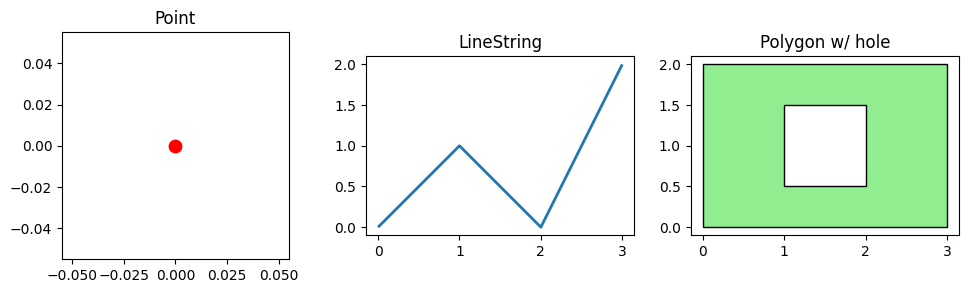

In [35]:
pt = Point(0, 0)
ln = LineString([(0, 0), (1, 1), (2, 0), (3, 2)])
pg = Polygon([(0, 0), (3, 0), (3, 2), (0, 2)], holes=[[(1, 0.5), (2, 0.5), (2, 1.5), (1, 1.5)]])

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
gpd.GeoSeries([pt]).plot(ax=axes[0], color="red", markersize=80); axes[0].set_title("Point")
gpd.GeoSeries([ln]).plot(ax=axes[1], linewidth=2);                axes[1].set_title("LineString")
gpd.GeoSeries([pg]).plot(ax=axes[2], color="lightgreen", edgecolor="k"); axes[2].set_title("Polygon w/ hole")
for a in axes: a.set_aspect("equal")
plt.tight_layout(); plt.show()


In [36]:
# Geometries expose handy attributes
print("Area of pg :", pg.area)
print("Length of ln:", ln.length)
print("Bounds of pg:", pg.bounds)   # (minx, miny, maxx, maxy)
print("Is valid?   :", pg.is_valid)


Area of pg : 5.0
Length of ln: 5.06449510224598
Bounds of pg: (0.0, 0.0, 3.0, 2.0)
Is valid?   : True


## 6 · Centroids

The geometric center of a polygon (or line).

Used for:
- placing labels
- assigning a single coordinate to a region
- nearest-neighbor joins polygon → polygon

⚠️ Centroid of a polygon in `EPSG:4326` is **biased** — reproject first.


In [59]:
peru_box = gpd.GeoDataFrame(
    {"name": ["Peru (bbox)"]},
    geometry=[box(-81.3, -18.4, -68.7, -0.0)],
    crs="EPSG:4326",
)

# bad: centroid in degrees
bad = peru_box.geometry.centroid.iloc[0]

# good: project to a metric CRS first
good = peru_box.to_crs(peru_box.estimate_utm_crs()).geometry.centroid.iloc[0]
good_ll = gpd.GeoSeries([good], crs=peru_box.estimate_utm_crs()).to_crs(4326).iloc[0]

print("Centroid (deg, biased) :", bad)
print("Centroid (UTM → back)  :", good_ll)


Centroid (deg, biased) : POINT (-74.99999999999999 -9.2)
Centroid (UTM → back)  : POINT (-75 -9.173756080429468)


## 7 · Buffers

A buffer is **every point within distance _d_ of a geometry**.

Common uses:
- "everything within 500 m of a road"
- "1 km exclusion zone around a school"
- Convert points → polygons for joins

Buffer distance is in the **CRS units**, so reproject to meters first.


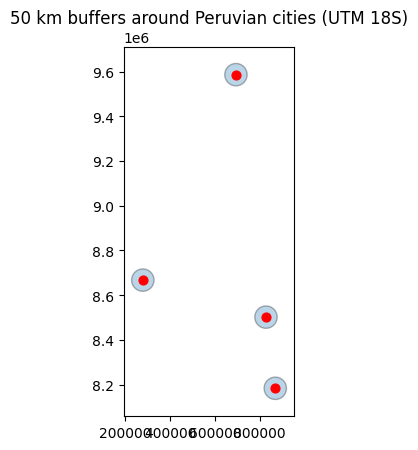

In [38]:
cities_m = cities.to_crs(cities.estimate_utm_crs())

cities_m["buf_50km"] = cities_m.buffer(50_000)   # 50 km

ax = cities_m.set_geometry("buf_50km").plot(alpha=0.3, edgecolor="k")
cities_m.plot(ax=ax, color="red", markersize=40)
ax.set_title("50 km buffers around Peruvian cities (UTM 18S)")
plt.show()


## 8 · Reading & writing vector files

GeoPandas reads almost any vector format through `read_file`:

- **Shapefile** (`.shp` + sidecars) — old, ubiquitous
- **GeoPackage** (`.gpkg`) — modern, single file, recommended
- **GeoJSON** (`.geojson`) — text, web-friendly
- **GeoParquet** (`.parquet`) — columnar, huge files, lightning fast (we'll cover this later)


In [60]:
# Download a small Natural Earth shapefile (1.1 MB) — countries of the world
import urllib.request, zipfile, io, tempfile, os

URL = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
tmp = tempfile.mkdtemp()
zip_path = os.path.join(tmp, "ne.zip")
urllib.request.urlretrieve(URL, zip_path)
with zipfile.ZipFile(zip_path) as z:
    z.extractall(tmp)

world = gpd.read_file(os.path.join(tmp, "ne_110m_admin_0_countries.shp"))
world = world[["NAME", "CONTINENT", "POP_EST", "geometry"]]
world.head()


,NAME,CONTINENT,POP_EST,geometry
0,Fiji,Oceania,889953.0,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Tanzania,Africa,58005463.0,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,W. Sahara,Africa,603253.0,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Canada,North America,37589262.0,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,United States of America,North America,328239523.0,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


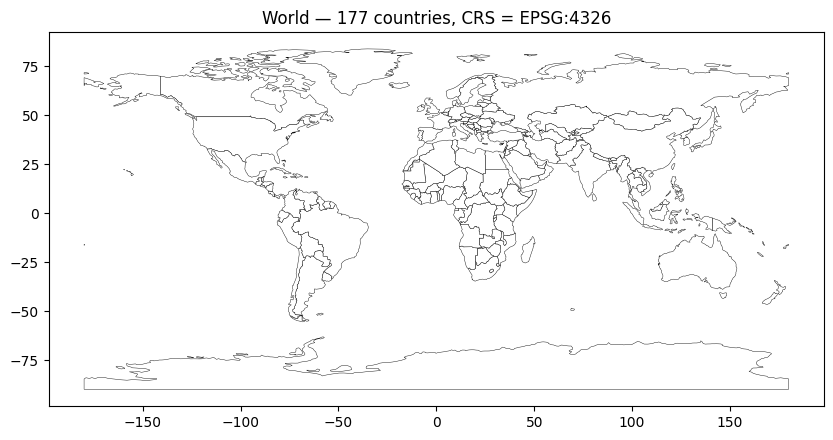

In [61]:
ax = world.plot(figsize=(10, 5), color="white", edgecolor="black", linewidth=0.3)
ax.set_title(f"World — {len(world)} countries, CRS = {world.crs.to_string()}")
plt.show()


In [63]:
# Write to other formats (round-trip)
world.to_file("/tmp/world.gpkg", driver="GPKG")        # GeoPackage
world.to_file("/tmp/world.geojson", driver="GeoJSON")  # GeoJSON
print(os.listdir("/tmp/"))


['zeb_def_ipc_16414', 'zeb_def_ipc_74609', 'zeb_def_ipc_62700', 'zeb_def_ipc_19261', 'diag.out', 'zeb_def_ipc_9419', 'zeb_def_ipc_64607', 'world.parquet', 'temp.nc', 'zeb_def_ipc_67079', 'zeb_def_ipc_28376', '.X0-lock', '3df2f3ff-34e6-41ca-bab3-094200688bb1', 'zeb_def_ipc_10607', '.ICE-unix', 'zeb_def_ipc_68346', 'zeb_def_ipc_10609', 'zeb_def_ipc_41468', 'zeb_def_ipc_35945', 'zeb_def_ipc_15794', 'zeb_def_ipc_37250', 'zeb_def_ipc_926', 'world.gpkg', 'zeb_def_ipc_88122', 'elev.tif', 'zeb_def_ipc_26894', 'zeb_def_ipc_96795', 'zeb_def_ipc_39280', 'zeb_def_ipc_46346', '.X11-unix', 'zeb_def_ipc_83062', 'zeb_def_ipc_75142', 'zeb_def_ipc_2052', 'zeb_def_ipc_5648', 'zeb_def_ipc_8701', 'zeb_def_ipc_80679', 'com.apple.launchd.VYCuI4nGUi', 'zeb_def_ipc_6635', 'com.apple.launchd.yjwpcqDmKK', 'zeb_def_ipc_60465', 'zeb_def_ipc_23966', 'zeb_def_ipc_36703', 'Visual Studio Code-38b55bce-755e-4d51-9104-18cd25b4e02c.sock', 'zeb_def_ipc_13283', 'zeb_def_ipc_32164', 'zeb_def_ipc_39345', 'diag.R', 'zeb_def_i

## 9 · Intersection & overlay

Set-theoretic operations on geometries:

- **intersection** — the area in **both** A and B
- **union** — area in A **or** B
- **difference** — A **minus** B
- **symmetric difference** — XOR

`gpd.overlay(a, b, how=...)` applies these between two whole layers.


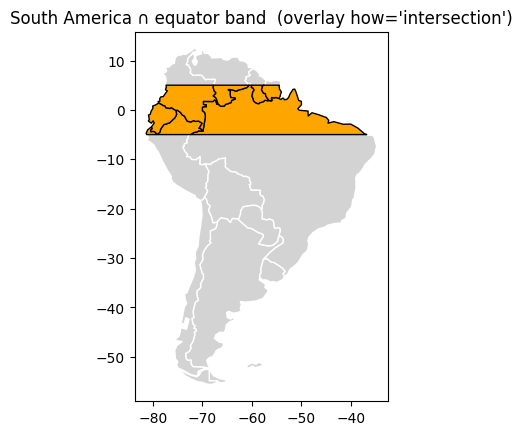

In [42]:
south_america = world[world.CONTINENT == "South America"].copy()
equator_band = gpd.GeoDataFrame(
    {"name": ["±5° equator band"]},
    geometry=[box(-180, -5, 180, 5)],
    crs="EPSG:4326",
)

tropical_sa = gpd.overlay(south_america, equator_band, how="intersection")
ax = south_america.plot(color="lightgrey", edgecolor="white")
tropical_sa.plot(ax=ax, color="orange", edgecolor="k")
ax.set_title("South America ∩ equator band  (overlay how='intersection')")
plt.show()


<Axes: >

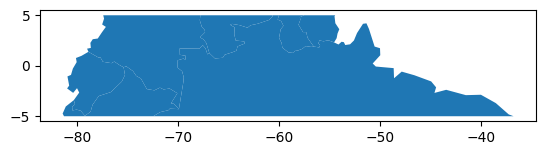

In [64]:
tropical_sa.plot()

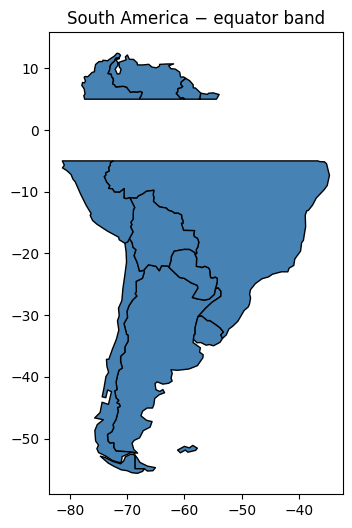

In [43]:
# difference: SA minus equator band
non_tropical = gpd.overlay(south_america, equator_band, how="difference")
non_tropical.plot(figsize=(6, 6), color="steelblue", edgecolor="k")
plt.title("South America − equator band")
plt.show()


## 10 · Dissolve & disaggregate

- **dissolve** → merge many polygons into one (group-by in space)
- **explode** → split a MultiPolygon back into its parts (disaggregate)

Together they let you move freely between "fine pieces" and "summary shapes".


In [66]:
world.head()

,NAME,CONTINENT,POP_EST,geometry
0,Fiji,Oceania,889953.0,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Tanzania,Africa,58005463.0,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,W. Sahara,Africa,603253.0,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Canada,North America,37589262.0,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,United States of America,North America,328239523.0,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


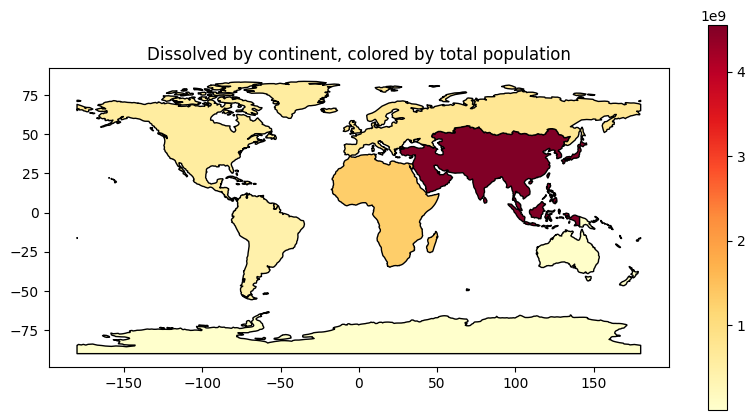

,POP_EST
CONTINENT,
Asia,4.550277e+09
Africa,1.306370e+09
Europe,7.454125e+08
North America,5.837560e+08
South America,4.270667e+08
Oceania,4.120487e+07
Antarctica,4.490000e+03
Seven seas (open ocean),1.400000e+02


In [44]:
continents = world.dissolve(by="CONTINENT", aggfunc={"POP_EST": "sum"})
continents.plot(column="POP_EST", legend=True, figsize=(10, 5),
                cmap="YlOrRd", edgecolor="k")
plt.title("Dissolved by continent, colored by total population")
plt.show()
continents[["POP_EST"]].sort_values("POP_EST", ascending=False)


In [45]:
# Disaggregate: each continent's MultiPolygon -> many Polygon rows
parts = continents.explode(index_parts=False).reset_index()
print(f"After explode: {len(parts)} pieces (was {len(continents)} continents)")
parts.head()


After explode: 134 pieces (was 8 continents)


,CONTINENT,POP_EST,geometry
0,Africa,1.306370e+09,"POLYGON ((-11.43878 6.78592, -11.70819 6.8601,..."
1,Africa,1.306370e+09,"POLYGON ((50.20027 -16.00026, 49.86061 -15.414..."
2,Antarctica,4.490000e+03,"POLYGON ((-61.13898 -79.98137, -60.61012 -79.6..."
3,Antarctica,4.490000e+03,"POLYGON ((-45.15476 -78.04707, -43.92083 -78.4..."
4,Antarctica,4.490000e+03,"POLYGON ((-161.24511 -78.38018, -160.24621 -78..."


## 11 · Spatial joins — `sjoin` and `sjoin_nearest`

A regular join uses a key column. A **spatial join** uses geometry:

- `gpd.sjoin(left, right, predicate="within")` — which polygon does each point fall in?
- `predicate` can be `intersects`, `within`, `contains`, `touches`, `crosses`, ...
- `gpd.sjoin_nearest(left, right)` — nearest feature (e.g., nearest city to each fire)


In [67]:
# Which country does each city belong to?
joined = gpd.sjoin(cities, world, predicate="within", how="left")
# joined[["name", "NAME", "CONTINENT"]]
joined


,name,geometry,index_right,NAME,CONTINENT,POP_EST
0,Lima,POINT (-77.0428 -12.0464),31,Peru,South America,32510453.0
1,Cusco,POINT (-71.9675 -13.532),31,Peru,South America,32510453.0
2,Arequipa,POINT (-71.5375 -16.3989),31,Peru,South America,32510453.0
3,Iquitos,POINT (-73.2536 -3.7437),31,Peru,South America,32510453.0


In [47]:
# Nearest city to a set of random points in Peru
rng = np.random.default_rng(0)
random_pts = gpd.GeoDataFrame(
    {"id": range(5)},
    geometry=gpd.points_from_xy(
        rng.uniform(-78, -70, 5),
        rng.uniform(-15, -5, 5),
    ),
    crs="EPSG:4326",
)
nearest = gpd.sjoin_nearest(random_pts.to_crs(32718),
                            cities.to_crs(32718),
                            distance_col="dist_m")
nearest[["id", "name", "dist_m"]]


,id,name,dist_m
0,0,Iquitos,238607.378433
1,1,Lima,368523.943637
2,2,Lima,485332.014855
3,3,Lima,289197.162857
4,4,Iquitos,287460.525340


## 15 · Raster data — the other half of GIS

Rasters are **grids of pixels** (elevation, temperature, satellite imagery).

Key concepts:
- A raster has a **CRS** and an **affine transform** mapping (col, row) → (x, y)
- Each band is a 2-D array; multi-band rasters stack bands (e.g., RGB)

Main libraries:
- **rasterio** — low-level reads/writes of GeoTIFF
- **rioxarray** — labels rasterio arrays with `xarray` (recommended)
- **xarray** — N-dimensional labelled arrays, perfect for NetCDF


In [70]:
import rasterio
from rasterio.transform import from_origin

# Build a synthetic 100x100 elevation raster centered on Lima
height, width = 100, 100
data = (np.indices((height, width)).sum(axis=0) * 10).astype("float32")
transform = from_origin(west=-77.2, north=-11.9, xsize=0.005, ysize=0.005)

with rasterio.open(
    "/tmp/elev.tif", "w",
    driver="GTiff", height=height, width=width, count=1,
    dtype=data.dtype, crs="EPSG:4326", transform=transform,
) as dst:
    dst.write(data, 1)

with rasterio.open("/tmp/elev.tif") as src:
    print("CRS      :", src.crs)
    print("Shape    :", src.shape)
    print("Bounds   :", src.bounds)
    print("Transform:", src.transform)


CRS      : EPSG:4326
Shape    : (100, 100)
Bounds   : BoundingBox(left=-77.2, bottom=-12.4, right=-76.7, top=-11.9)
Transform: | 0.01, 0.00,-77.20|
| 0.00,-0.01,-11.90|
| 0.00, 0.00, 1.00|


<xarray.DataArray (y: 100, x: 100)> Size: 40kB
[10000 values with dtype=float32]
Coordinates:
  * y            (y) float64 800B -11.9 -11.91 -11.91 ... -12.39 -12.39 -12.4
  * x            (x) float64 800B -77.2 -77.19 -77.19 ... -76.71 -76.71 -76.7
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0


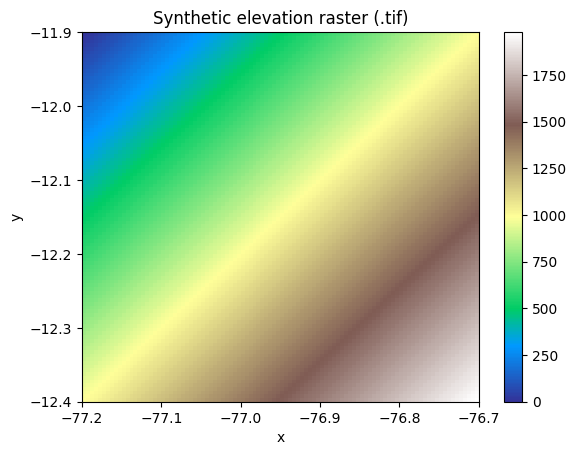

In [71]:
import rioxarray as rxr
ras = rxr.open_rasterio("/tmp/elev.tif").squeeze()
print(ras)

ras.plot(cmap="terrain")
plt.title("Synthetic elevation raster (.tif)")
plt.show()


## 16 · NetCDF (`.nc`) — multi-dimensional climate data

NetCDF stores N-D arrays with labels (time × lat × lon × …).
Almost every climate / ocean / atmospheric dataset ships as NetCDF.

`xarray` is the tool of choice.


In [76]:
import xarray as xr

# Build a synthetic temperature cube: (time, lat, lon)
times = pd.date_range("2024-01-01", periods=12, freq="MS")
lats = np.linspace(-20, 0, 21)
lons = np.linspace(-82, -68, 15)
temp = 25 - 0.5 * np.abs(lats[None, :, None]) \
         + 3 * np.sin(2 * np.pi * np.arange(12)[:, None, None] / 12) \
         + np.random.default_rng(1).normal(0, 0.5, (12, 21, 15))

ds = xr.Dataset(
    {"temperature": (("time", "lat", "lon"), temp.astype("float32"))},
    coords={"time": times, "lat": lats, "lon": lons},
    attrs={"description": "Synthetic monthly mean temperature"},
)
ds.to_netcdf("/Users/anzony.quisperojas/Documents/GitHub/python/GeoAgent/Lectures/temp.nc")


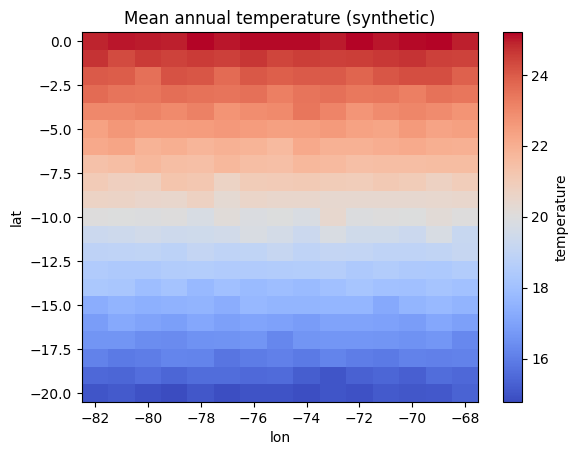

In [ ]:
ds2 = xr.open_dataset("/tmp/temp.nc")
ds2["temperature"].mean("time").plot(cmap="coolwarm")
plt.title("Mean annual temperature (synthetic)")
plt.show()


## 19 · Zonal statistics

**Question**: for each polygon, what's the mean / max / sum of a raster inside it?

Examples:
- mean elevation per municipality
- total rainfall per watershed
- max NDVI per farm plot

Library: `rasterstats` (or do it manually with `rioxarray` + `xarray`).


In [79]:
# Make 4 sample polygons covering the synthetic elevation raster
zones = gpd.GeoDataFrame(
    {"zone": ["NW", "NE", "SW", "SE"]},
    geometry=[
        box(-77.2, -12.15, -76.95, -11.9),
        box(-76.95, -12.15, -76.7, -11.9),
        box(-77.2, -12.4, -76.95, -12.15),
        box(-76.95, -12.4, -76.7, -12.15),
    ],
    crs="EPSG:4326",
)

from rasterstats import zonal_stats
stats = zonal_stats(zones, "/tmp/elev.tif", stats=["mean", "min", "max", "count"])
zones = zones.join(pd.DataFrame(stats))
zones[["zone", "mean", "min", "max", "count"]]


,zone,mean,min,max,count
0,NW,490.0,0.0,980.0,2500
1,NE,990.0,500.0,1480.0,2500
2,SW,990.0,500.0,1480.0,2500
3,SE,1490.0,1000.0,1980.0,2500


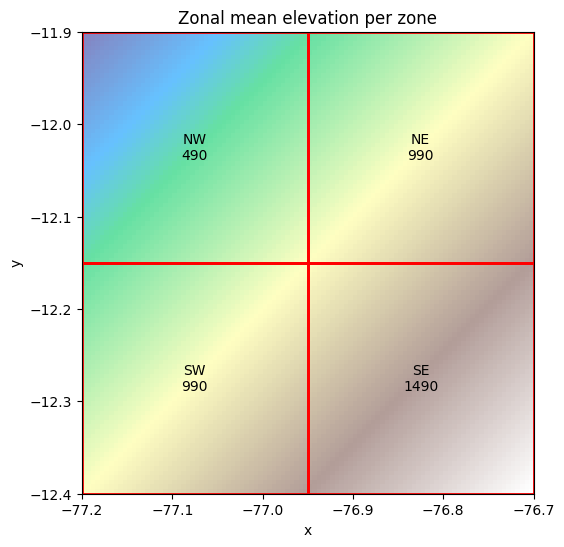

In [78]:
fig, ax = plt.subplots(figsize=(6, 6))
ras.plot(ax=ax, cmap="terrain", alpha=0.6, add_colorbar=False)
zones.boundary.plot(ax=ax, color="red", linewidth=2)
for _, r in zones.iterrows():
    c = r.geometry.centroid
    ax.text(c.x, c.y, f"{r.zone}\n{r['mean']:.0f}", ha="center", va="center")
plt.title("Zonal mean elevation per zone")
plt.show()


## 23 · Where to go next

- **Books**: *Geographic Data Science with Python* (Rey, Arribas-Bel, Wolf, 2023) — free online
- **Tutorials**: geopandas.org, automating-gis-processes.github.io
- **Big-data geo**: Dask-GeoPandas, Apache Sedona, DuckDB-spatial
- **Cloud-native rasters**: COG, STAC catalogs, Planetary Computer
- **Spatial statistics**: PySAL (Moran's I, hotspot analysis)
- **Networks / routing**: OSMnx + NetworkX

### Thank you!

Questions, ideas, corrections → anzony.quispe@gmail.com
